<a href="https://colab.research.google.com/github/Calemite/drug-classification-ml/blob/main/clasification_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Objectives

After completing this lab you will be able to:

*   Develop a various classification algorithms

In this lab exercise, you will learn a various classification machine learning algorithms. You will use the classification algorithms to build a model from the historical data of patients, and their response to different medications. Then you will use the trained decision tree to predict the class of an unknown patient, or to find a proper drug for a new patient.


<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="https://#about_dataset">About the dataset</a></li>
        <li><a href="https://#downloading_data">Downloading the Data</a></li>
        <li><a href="https://#pre-processing">Pre-processing</a></li>
        <li><a href="https://#setting_up_tree">Setting up the Decision Tree</a></li>
        <li><a href="https://#modeling">Modeling</a></li>
        <li><a href="https://#prediction">Prediction</a></li>
        <li><a href="https://#evaluation">Evaluation</a></li>
        <li><a href="https://#visualization">Visualization</a></li>
    </ol>
</div>
<br>
<hr>


Import the Following Libraries:

<ul>
    <li> <b>numpy as np</b> </li>
    <li> <b>pandas as pd</b> </li>
    <li> <b>matplotlib.pyplot as plt</b> </li>
    <li> <b>seaborn as sns</b> </li>
    <li> <b>train_test_split</b> from <b>sklearn.model_selection</b> </li>
    <li> <b>LabelEncoder or OneHotEncoder</b> (which ever you prefer) from <b>sklearn.preprocessing</b> </li>
    <li> <b>GausianNB</b> from <b>sklearn.naive_bayes</b> </li>
    <li> <b>metrics</b> from <b>sklearn.metrics</b> </li>

</ul>


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

<div id="about_dataset">
    <h2>About the dataset</h2>
    Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.
    <br>
    <br>
    Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.
    <br>
    <br>
    It is a sample of multiclass classifier, and you can use the training part of the dataset
    to build a decision tree, and then use it to predict the class of an unknown patient, or to prescribe a drug to a new patient.
    <br>
    Typical features in the dataset:
     <li>Age (numeric)
     <li>Sex (categorical: M, F)
     <li>BP (categorical: HIGH, NORMAL, LOW)
     <li>Cholesterol (categorical: HIGH, NORMAL)
     <li>Na_to_K (numeric: Sodium/Potassium ratio)
     <li>Drug (target label)
</div>


<div id="downloading_data">
    <h2>Load the Data</h2>
</div>

Now, load the data using pandas dataframe:


In [ ]:
drug = pd.read_csv('drug200.csv')

<div id="Explore the data">
    <h3>Explore the data</h3>
    What is the size of data?
    What is the data descriptive?
</div>


In [ ]:
print(drug.shape)
print(drug.describe(include = 'all'))


(200, 6)
               Age  Sex    BP Cholesterol     Na_to_K   Drug
count   200.000000  200   200         200  200.000000    200
unique         NaN    2     3           2         NaN      5
top            NaN    M  HIGH        HIGH         NaN  drugY
freq           NaN  104    77         103         NaN     91
mean     44.315000  NaN   NaN         NaN   16.084485    NaN
std      16.544315  NaN   NaN         NaN    7.223956    NaN
min      15.000000  NaN   NaN         NaN    6.269000    NaN
25%      31.000000  NaN   NaN         NaN   10.445500    NaN
50%      45.000000  NaN   NaN         NaN   13.936500    NaN
75%      58.000000  NaN   NaN         NaN   19.380000    NaN
max      74.000000  NaN   NaN         NaN   38.247000    NaN


<div href="pre-processing">
    <h2>Pre-processing</h2>
</div>


Using <b>my_data</b> as the Drug.csv data read by pandas, declare the following variables: <br>

<ul>
    <li> <b> X </b> as the <b> Feature Matrix </b> (data of my_data) </li>
    <li> <b> X </b> is 'Age', 'Sex_n', 'BP_n', 'Chol_n', 'Na_to_K'</li>
    <li> <b> Y </b> as the <b> response vector </b> (target) </li>
    <li> Y is 'Drug'</li>
</ul>


Remove the column containing the target name since it doesn't contain numeric values.


In [ ]:
le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_chol = LabelEncoder()

In [ ]:
drug['Sex_n'] = le_sex.fit_transform(drug['Sex'])
drug['BP_n'] = le_bp.fit_transform(drug['BP'])
drug['Chol_n'] = le_chol.fit_transform(drug['Cholesterol'])

In [ ]:
X = drug[['Age', 'Sex_n', 'BP_n', 'Chol_n', 'Na_to_K']]
Y = drug['Drug']

As you may figure out, some features in this dataset are categorical, such as **Sex** or **BP**. Convert the categorical variable into dummy/indicator variables.


In [ ]:

drug.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Sex_n,BP_n,Chol_n
0,23,F,HIGH,HIGH,25.355,drugY,0,0,0
1,47,M,LOW,HIGH,13.093,drugC,1,1,0
2,47,M,LOW,HIGH,10.114,drugC,1,1,0
3,28,F,NORMAL,HIGH,7.798,drugX,0,2,0
4,61,F,LOW,HIGH,18.043,drugY,0,1,0


Print the target variable.


In [ ]:
#print y
print(Y)

0      drugY
1      drugC
2      drugC
3      drugX
4      drugY
       ...  
195    drugC
196    drugC
197    drugX
198    drugX
199    drugX
Name: Drug, Length: 200, dtype: object


<hr>

<div id="Model Setting">
    <h2>Setting up the Naive Bayes Algorithm</h2>
    We will be using <b>train/test split</b> on our algorithms </b>. Let's import <b>train_test_split</b> from <b>sklearn.model_selection</b>.
</div>


Now <b> train_test_split </b> will return 4 different parameters. We will name them:<br>
X_trainset, X_testset, Y_trainset, Y_testset <br> <br>
The <b> train_test_split </b> will need the parameters: <br>
X, y, test_size=0.3, and random_state=3. <br> <br>
The <b>X</b> and <b>y</b> are the arrays required before the split, the <b>test_size</b> represents the ratio of the testing dataset, and the <b>random_state</b> ensures that the dataset were split at random with consistent shuffle.


In [ ]:
#write your code here
X_trainset, X_testset, Y_trainset, Y_testset = train_test_split(X, Y, test_size = 0.3, random_state = 3)



Print the shape of X_trainset and y_trainset. Ensure that the dimensions match the prior splitting request.


In [ ]:
print(f"X_trainset : {X_trainset.shape}, Y_trainset : {Y_trainset.shape}")


X_trainset : (140, 5), Y_trainset : (140,)



Print the shape of X_testset and y_testset.


In [ ]:
# your code
print(f"X_testset : {X_testset.shape}, Y_testset : {Y_testset.shape}")


X_testset : (60, 5), Y_testset : (60,)


<hr>

<div id="modeling">
    <h2>Modeling</h2>
    Lets create an instance of the <b>Naive Bayes</b>.

</div>


In [ ]:
# Create a Naive Bayes classifier and name it as Model_NB1

Model_NB1 = GaussianNB()
Model_NB2 = CategoricalNB()
Model_NB3 = MultinomialNB()
Model_NB4 = BernoulliNB()

Next, we will fit the data with the training feature matrix <b> X_trainset </b> and training  response vector <b> y_trainset </b>


In [ ]:
# Train the classifier with X_trainset and Y_trainset

Model_NB1.fit(X_trainset, Y_trainset)
Model_NB2.fit(X_trainset, Y_trainset)
Model_NB3.fit(X_trainset, Y_trainset)
Model_NB4.fit(X_trainset, Y_trainset)

BernoulliNB()

<hr>

<div id="prediction">
    <h2>Prediction</h2>
    Let's make some <b>predictions</b> on the testing dataset and store it into a variable called <b>predNB1</b>.
</div>


In [ ]:
#make prediction for Model_NB1 (Naive Bayes)

predNB1 = Model_NB1.predict(X_testset) # GaussianNB()
predNB2 = Model_NB2.predict(X_testset) # CategoricalNB()
predNB3 = Model_NB3.predict(X_testset) # MultinomialNB()
predNB4 = Model_NB4.predict(X_testset) # BernoulliNB()

You can print out <b>predNB1</b> and <b>y_testset</b> if you want to visually compare the predictions to the actual values.





In [ ]:
#Compare the predicted Y for Model_NB1 vs Actual Y Test
# GaussianNB()
print(predNB1)
print(Y_testset)

['drugY' 'drugX' 'drugX' 'drugX' 'drugX' 'drugC' 'drugA' 'drugA' 'drugB'
 'drugA' 'drugY' 'drugA' 'drugY' 'drugY' 'drugX' 'drugY' 'drugX' 'drugX'
 'drugB' 'drugX' 'drugX' 'drugB' 'drugC' 'drugY' 'drugX' 'drugB' 'drugY'
 'drugY' 'drugA' 'drugX' 'drugB' 'drugC' 'drugC' 'drugX' 'drugX' 'drugC'
 'drugC' 'drugX' 'drugX' 'drugX' 'drugA' 'drugA' 'drugC' 'drugA' 'drugA'
 'drugY' 'drugY' 'drugY' 'drugC' 'drugY' 'drugB' 'drugX' 'drugY' 'drugX'
 'drugY' 'drugB' 'drugA' 'drugX' 'drugY' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
82     drugC
183    drugY
46     drugA
70     drugB
100    drugA
179    drugY
83     drugA
25     drugY
190    drugY
159    drugX
173    drugY
95     drugX
3      drugX
41     drugB
58     drugX
14     drugX
143    drugY
12     drugY
6      drugY
182    drugX
161    drugB
128    drugY
122    drugY
101    drugA
86     drugX
64     drugB
47     drugC
158    drugC
34     drugX
38     drugX
196    drugC
4      drugY
72     drugX
67     drugX
145  

In [ ]:
# CategoricalNB()
print(predNB2)
print(Y_testset)

['drugY' 'drugX' 'drugX' 'drugX' 'drugX' 'drugX' 'drugY' 'drugY' 'drugB'
 'drugB' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX' 'drugY' 'drugX' 'drugX'
 'drugY' 'drugX' 'drugX' 'drugY' 'drugY' 'drugY' 'drugX' 'drugY' 'drugY'
 'drugY' 'drugA' 'drugX' 'drugB' 'drugC' 'drugC' 'drugX' 'drugX' 'drugC'
 'drugY' 'drugX' 'drugX' 'drugX' 'drugB' 'drugY' 'drugX' 'drugY' 'drugB'
 'drugY' 'drugY' 'drugY' 'drugY' 'drugX' 'drugA' 'drugX' 'drugY' 'drugX'
 'drugY' 'drugY' 'drugB' 'drugX' 'drugY' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
82     drugC
183    drugY
46     drugA
70     drugB
100    drugA
179    drugY
83     drugA
25     drugY
190    drugY
159    drugX
173    drugY
95     drugX
3      drugX
41     drugB
58     drugX
14     drugX
143    drugY
12     drugY
6      drugY
182    drugX
161    drugB
128    drugY
122    drugY
101    drugA
86     drugX
64     drugB
47     drugC
158    drugC
34     drugX
38     drugX
196    drugC
4      drugY
72     drugX
67     drugX
145  

In [ ]:
# MultinomialNB()
print(predNB3)
print(Y_testset)

['drugX' 'drugX' 'drugX' 'drugX' 'drugY' 'drugX' 'drugY' 'drugY' 'drugB'
 'drugY' 'drugX' 'drugA' 'drugY' 'drugA' 'drugY' 'drugY' 'drugX' 'drugX'
 'drugA' 'drugX' 'drugX' 'drugB' 'drugY' 'drugX' 'drugY' 'drugB' 'drugY'
 'drugY' 'drugA' 'drugX' 'drugB' 'drugX' 'drugX' 'drugX' 'drugX' 'drugY'
 'drugC' 'drugY' 'drugY' 'drugX' 'drugA' 'drugA' 'drugX' 'drugY' 'drugY'
 'drugA' 'drugY' 'drugC' 'drugX' 'drugX' 'drugB' 'drugX' 'drugX' 'drugX'
 'drugY' 'drugA' 'drugA' 'drugY' 'drugY' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
82     drugC
183    drugY
46     drugA
70     drugB
100    drugA
179    drugY
83     drugA
25     drugY
190    drugY
159    drugX
173    drugY
95     drugX
3      drugX
41     drugB
58     drugX
14     drugX
143    drugY
12     drugY
6      drugY
182    drugX
161    drugB
128    drugY
122    drugY
101    drugA
86     drugX
64     drugB
47     drugC
158    drugC
34     drugX
38     drugX
196    drugC
4      drugY
72     drugX
67     drugX
145  

In [ ]:
# BernoulliNB()
print(predNB4)
print(Y_testset)

['drugY' 'drugX' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY'
 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX' 'drugY'
 'drugY' 'drugX' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX'
 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY'
 'drugY' 'drugY' 'drugX' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY'
 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX'
 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
82     drugC
183    drugY
46     drugA
70     drugB
100    drugA
179    drugY
83     drugA
25     drugY
190    drugY
159    drugX
173    drugY
95     drugX
3      drugX
41     drugB
58     drugX
14     drugX
143    drugY
12     drugY
6      drugY
182    drugX
161    drugB
128    drugY
122    drugY
101    drugA
86     drugX
64     drugB
47     drugC
158    drugC
34     drugX
38     drugX
196    drugC
4      drugY
72     drugX
67     drugX
145  

<hr>

<div id="evaluation">
    <h2>Evaluation</h2>
    Next, let's check the accuracy of our model.
</div>


In [ ]:
#check the confusion matrix
# GaussianNB()
conf1 = confusion_matrix(Y_testset, predNB1, )
print(conf1)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 3  2  3  0 14]]


In [ ]:
# CategoricalNB()
conf2 = confusion_matrix(Y_testset, predNB2, )
print(conf2)

[[ 1  4  0  0  2]
 [ 1  2  0  0  2]
 [ 0  0  3  2  0]
 [ 0  0  0 21  0]
 [ 0  0  0  0 22]]


In [ ]:
# MultinomialNB()
conf3 = confusion_matrix(Y_testset, predNB3, )
print(conf3)

[[ 4  0  0  0  3]
 [ 1  4  0  0  0]
 [ 0  0  0  4  1]
 [ 0  0  0 15  6]
 [ 4  1  2  5 10]]


In [ ]:
# BernoulliNB()
conf4 = confusion_matrix(Y_testset, predNB4, )
print(conf4)

[[ 0  0  0  0  7]
 [ 0  0  0  0  5]
 [ 0  0  0  0  5]
 [ 0  0  0  6 15]
 [ 0  0  0  1 21]]


In [ ]:
#check the accuracy
# GaussianNB()
acc1 = accuracy_score(Y_testset, predNB1)
print(acc1)

0.85


In [ ]:
# CategoricalNB()
acc2 = accuracy_score(Y_testset, predNB2)
print(acc2)

0.8166666666666667


In [ ]:
# MultinomialNB()
acc3 = accuracy_score(Y_testset, predNB3)
print(acc3)

0.55


In [ ]:
# BernoulliNB()
acc4 = accuracy_score(Y_testset, predNB4)
print(acc4)

0.45


In [ ]:
#check the classification report
# GaussianNB()
report1 = classification_report(Y_testset, predNB1)
print(report)

              precision    recall  f1-score   support

       drugA       0.70      1.00      0.82         7
       drugB       0.71      1.00      0.83         5
       drugC       0.62      1.00      0.77         5
       drugX       1.00      0.95      0.98        21
       drugY       0.93      0.64      0.76        22

    accuracy                           0.85        60
   macro avg       0.79      0.92      0.83        60
weighted avg       0.89      0.85      0.85        60



In [ ]:
# CategoricalNB()
report2 = classification_report(Y_testset, predNB2)
print(report2)

              precision    recall  f1-score   support

       drugA       0.50      0.14      0.22         7
       drugB       0.33      0.40      0.36         5
       drugC       1.00      0.60      0.75         5
       drugX       0.91      1.00      0.95        21
       drugY       0.85      1.00      0.92        22

    accuracy                           0.82        60
   macro avg       0.72      0.63      0.64        60
weighted avg       0.80      0.82      0.79        60



In [ ]:
# MultinomialNB()
report3 = classification_report(Y_testset, predNB3)
print(report3)

              precision    recall  f1-score   support

       drugA       0.44      0.57      0.50         7
       drugB       0.80      0.80      0.80         5
       drugC       0.00      0.00      0.00         5
       drugX       0.62      0.71      0.67        21
       drugY       0.50      0.45      0.48        22

    accuracy                           0.55        60
   macro avg       0.47      0.51      0.49        60
weighted avg       0.52      0.55      0.53        60



In [ ]:
# BernoulliNB()
report4 = classification_report(Y_testset, predNB4)
print(report4)

              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         7
       drugB       0.00      0.00      0.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.86      0.29      0.43        21
       drugY       0.40      0.95      0.56        22

    accuracy                           0.45        60
   macro avg       0.25      0.25      0.20        60
weighted avg       0.45      0.45      0.36        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Accuracy classification score** computes subset accuracy: the set of labels predicted for a sample must exactly match the corresponding set of labels in y_true.

In multilabel classification, the function returns the subset accuracy. If the entire set of predicted labels for a sample strictly matches with the true set of labels, then the subset accuracy is 1.0; otherwise it is 0.0.


<hr>

<div id="visualization">
    <h2>Visualization</h2>

Let's visualize Confusion Matrix using heatmap.

</div>


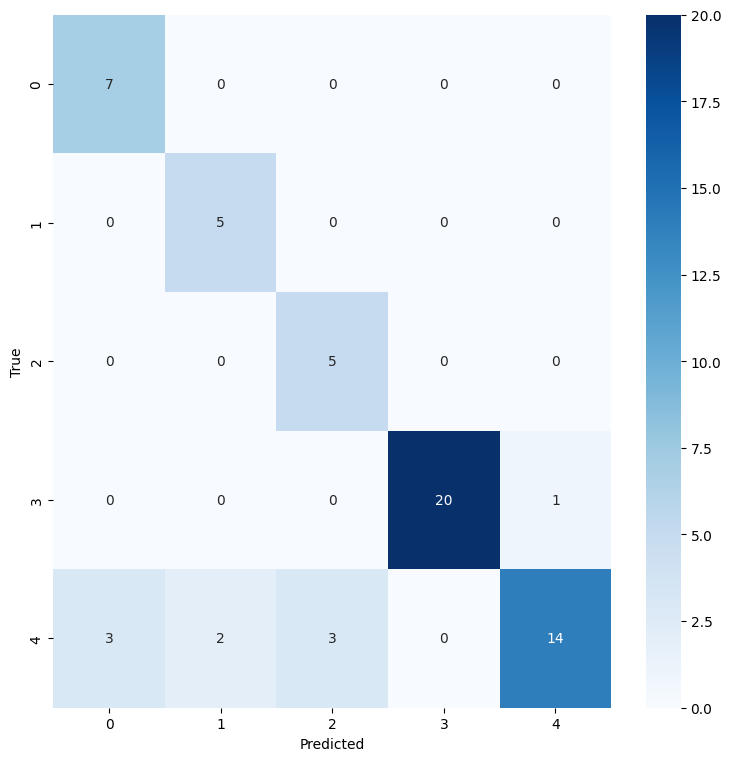

In [ ]:
#heatmap for confusion matrix
# GaussianNB()
plt.figure(figsize=(9,9))
sns.heatmap(conf1, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



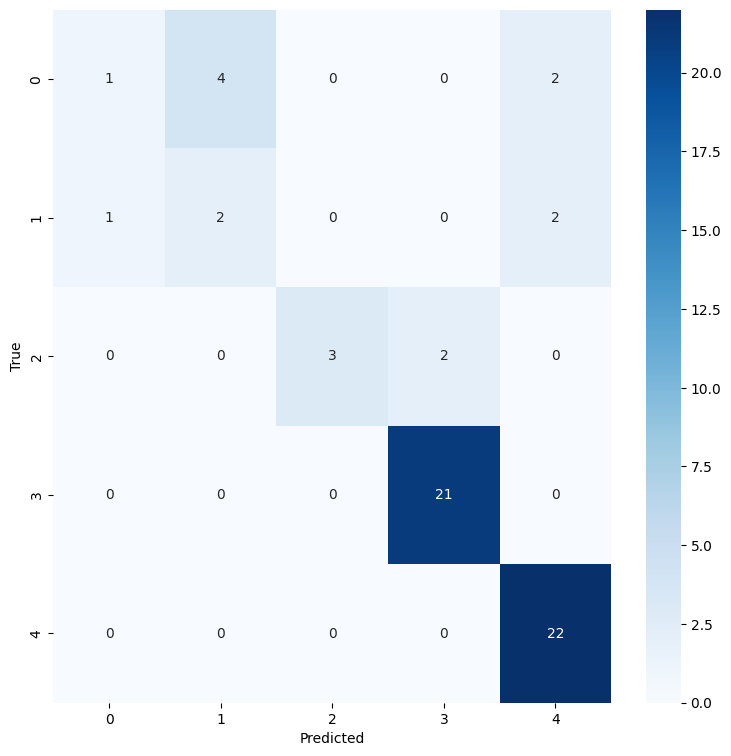

In [ ]:
# CategoricalNB()
plt.figure(figsize=(9,9))
sns.heatmap(conf2, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

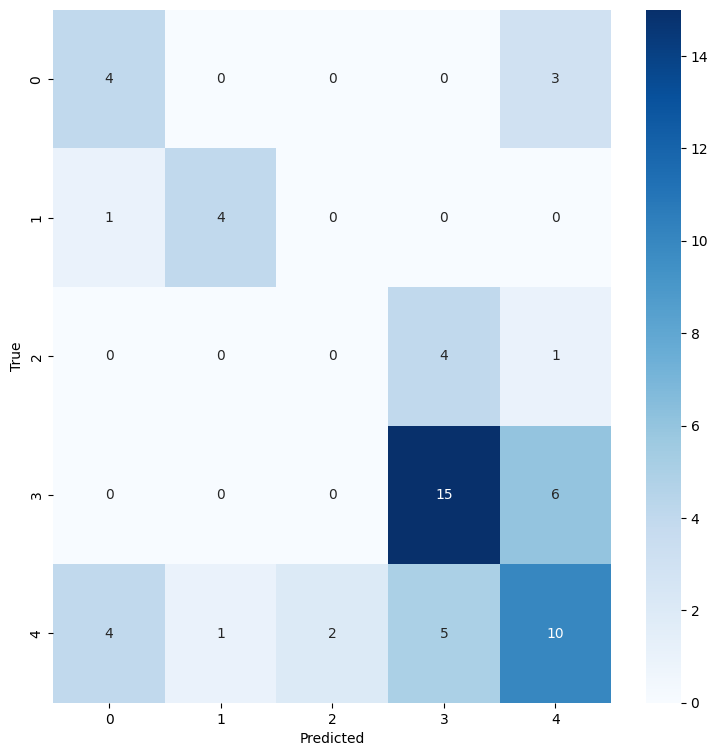

In [ ]:
# MultinomialNB()
plt.figure(figsize=(9,9))
sns.heatmap(conf3, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

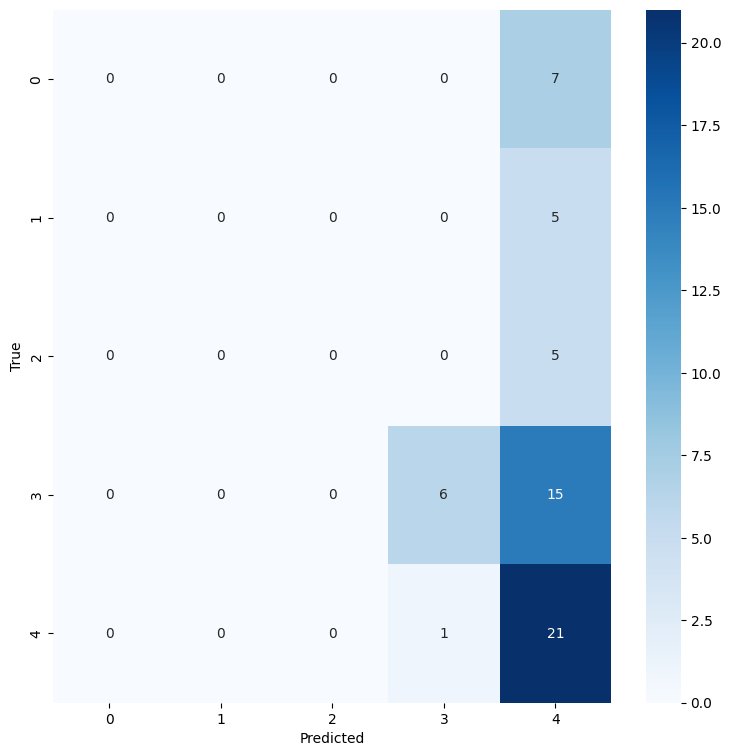

In [ ]:
# BernoulliNB()
plt.figure(figsize=(9,9))
sns.heatmap(conf4, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Another variant of Naive Bayes

In [ ]:
# try to set the parameter such as var_smoothing or alpha in the models
# let try using another variant of naive bayes such as Multinomial and Bernoulli
# split the data using cross validation technique
# compare the performance of each models

In [ ]:
#make prediction for Model_NB2 (Multinomial Naive Bayes)


[[ 4  0  0  0  3]
 [ 1  4  0  0  0]
 [ 0  0  0  4  1]
 [ 0  0  0 15  6]
 [ 4  1  2  5 10]]
0.55


In [ ]:
#make prediction for Model_NB3 (Categorical Naive Bayes)


[[ 1  4  0  0  2]
 [ 1  2  0  0  2]
 [ 0  0  3  2  0]
 [ 0  0  0 21  0]
 [ 0  0  0  0 22]]
0.8166666666666667


In [ ]:
#make prediction for Model_NB5 (Gaussian Naive Bayes) with alpha


[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  1  2  0 19]]
0.9333333333333333


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

Model_LR = LogisticRegression(max_iter=5000)
Model_LR.fit(X_trainset, Y_trainset)
predLR = Model_LR.predict(X_testset)

In [ ]:
conf_LR = confusion_matrix(Y_testset, predLR)
print(conf_LR)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 1  0  0  0 21]]


In [ ]:
acc_LR = accuracy_score(Y_testset, predLR)
print(acc_LR)

0.9666666666666667


In [ ]:
print(classification_report(Y_testset, predLR))

              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.95      0.95      0.95        22

    accuracy                           0.97        60
   macro avg       0.97      0.98      0.97        60
weighted avg       0.97      0.97      0.97        60



Another variant of Logistic Regression

In [ ]:
# Liblinear
Model_LR_lib = LogisticRegression(solver='liblinear', penalty='l1', max_iter=1000)
Model_LR_lib.fit(X_trainset, Y_trainset)
predLR_lib = Model_LR_lib.predict(X_testset)

In [ ]:
conf_LR_lib = confusion_matrix(Y_testset, predLR_lib)
print(conf_LR_lib)

[[ 6  0  0  0  1]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  1  0  0 21]]


In [ ]:
acc_LR_Lib = accuracy_score(Y_testset, predLR_lib)
print(acc_LR_Lib)

0.95


In [ ]:

print(classification_report(Y_testset, predLR_lib))

              precision    recall  f1-score   support

       drugA       1.00      0.86      0.92         7
       drugB       0.83      1.00      0.91         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.91      0.95      0.93        22

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



# Decison Tree

In [ ]:
# Gini Decision Tree

from sklearn.tree import DecisionTreeClassifier

Model_DT = DecisionTreeClassifier(criterion="gini", random_state=13)
Model_DT.fit(X_trainset, Y_trainset)
predDT = Model_DT.predict(X_testset)

In [ ]:
acc_DT = accuracy_score(Y_testset, predDT)
print(acc_DT)

0.9833333333333333


In [ ]:
conf_DT = confusion_matrix(Y_testset, predDT)
print(conf_DT)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]


In [ ]:
print(classification_report(Y_testset, predDT))

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



Another variant of Decision Tree

In [ ]:
# Entropy Decision Tree

Model_DTE = DecisionTreeClassifier(criterion="entropy", random_state=13)
Model_DTE.fit(X_trainset, Y_trainset)
predDTE = Model_DTE.predict(X_testset)

In [ ]:
acc_DTE = accuracy_score(Y_testset, predDTE)
print(acc_DTE)

0.9833333333333333


In [ ]:
conf_DTE = confusion_matrix(Y_testset, predDTE)
print(conf_DTE)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]


In [ ]:
print(classification_report(Y_testset, predDTE))

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



# Random Forest

In [ ]:
# Gini Random Forest
from sklearn.ensemble import RandomForestClassifier

Model_RF = RandomForestClassifier(n_estimators=100, criterion="gini", random_state=13)
Model_RF.fit(X_trainset, Y_trainset)
predRF = Model_RF.predict(X_testset)

In [ ]:
acc_RF = accuracy_score(Y_testset, predRF)
print(acc_RF)

0.9833333333333333


In [ ]:
conf_RF = confusion_matrix(Y_testset, predRF)
print(conf_RF)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]


In [ ]:
print(classification_report(Y_testset, predRF))

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

Model_KNN = KNeighborsClassifier(n_neighbors=5, weights='distance')
Model_KNN.fit(X_trainset, Y_trainset)
predKNN = Model_KNN.predict(X_testset)

In [ ]:
acc_KNN = accuracy_score(Y_testset, predKNN)
print(acc_KNN)

0.7


In [ ]:
conf_KNN = confusion_matrix(Y_testset, predKNN)
print(conf_KNN)

[[ 4  0  1  2  0]
 [ 0  4  0  0  1]
 [ 1  2  0  2  0]
 [ 2  3  1 13  2]
 [ 0  0  1  0 21]]


In [ ]:
print(classification_report(Y_testset, predKNN))

              precision    recall  f1-score   support

       drugA       0.57      0.57      0.57         7
       drugB       0.44      0.80      0.57         5
       drugC       0.00      0.00      0.00         5
       drugX       0.76      0.62      0.68        21
       drugY       0.88      0.95      0.91        22

    accuracy                           0.70        60
   macro avg       0.53      0.59      0.55        60
weighted avg       0.69      0.70      0.69        60



# Support Vector Machine (Classification)

In [ ]:
# Radial Basis Function

from sklearn.svm import SVC

Model_SVM = SVC(kernel='rbf', C=1.0, random_state=13)
Model_SVM.fit(X_trainset, Y_trainset)
predSVM = Model_SVM.predict(X_testset)

In [ ]:
acc_SVM = accuracy_score(Y_testset, predSVM)
print(acc_SVM)

0.7


In [ ]:
conf_SVM = confusion_matrix(Y_testset, predSVM)
print(conf_SVM)

[[ 0  0  0  7  0]
 [ 0  0  0  3  2]
 [ 0  0  0  5  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]


In [ ]:
print(classification_report(Y_testset, predSVM))

              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         7
       drugB       0.00      0.00      0.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.57      0.95      0.71        21
       drugY       0.88      1.00      0.94        22

    accuracy                           0.70        60
   macro avg       0.29      0.39      0.33        60
weighted avg       0.52      0.70      0.59        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Another variant of SVC

In [ ]:
# Linear

Model_SVML = SVC(kernel='linear', C=1.0, random_state=13)
Model_SVML.fit(X_trainset, Y_trainset)
predSVML = Model_SVML.predict(X_testset)

In [ ]:
acc_SVML = accuracy_score(Y_testset, predSVML)
print(acc_SVML)

0.9666666666666667


In [ ]:
conf_SVML = confusion_matrix(Y_testset, predSVML)
print(conf_SVML)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 1  0  0  0 21]]


In [ ]:
print(classification_report(Y_testset, predSVML))

              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.95      0.95      0.95        22

    accuracy                           0.97        60
   macro avg       0.97      0.98      0.97        60
weighted avg       0.97      0.97      0.97        60



Explain your findings

In [ ]:
import pandas as pd

# 1. Create a dictionary mapping each model variant to its stored variable
leaderboard_data = {
    "Algorithm": [
        "Naive Bayes", "Naive Bayes", "Naive Bayes", "Naive Bayes",
        "Logistic Regression", "Logistic Regression",
        "Decision Tree", "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors",
        "Support Vector Machine", "Support Vector Machine"
    ],
    "Variants": [
        "Gaussian NB", "Multinomial NB", "Complement NB", "Bernoulli NB",
        "Standard (lbfgs + L2)", "Tuned (liblinear + L1)",
        "Gini Split", "Entropy Split",
        "Gini Forest (100 Trees)",
        "Distance-Weighted (K=5)",
        "RBF Kernel", "Linear Kernel"
    ],
    "Accuracy Score": [

        acc1, acc2, acc3, acc4,
        acc_LR, acc_LR_Lib,
        acc_DT, acc_DTE,
        acc_RF,
        acc_KNN,
        acc_SVM, acc_SVML
    ]
}


df_leaderboard = pd.DataFrame(leaderboard_data)
df_leaderboard["Accuracy Score"] = df_leaderboard["Accuracy Score"].map(lambda x: f"{x * 100:.2f}%")
df_leaderboard = df_leaderboard.sort_values(by="Accuracy Score", ascending=False).reset_index(drop=True)


print(df_leaderboard.to_markdown(index=False))

| Algorithm              | Variant / Kernel        | Accuracy Score   |
|:-----------------------|:------------------------|:-----------------|
| Decision Tree          | Gini Split              | 98.33%           |
| Decision Tree          | Entropy Split           | 98.33%           |
| Random Forest          | Gini Forest (100 Trees) | 98.33%           |
| Logistic Regression    | Standard (lbfgs + L2)   | 96.67%           |
| Support Vector Machine | Linear Kernel           | 96.67%           |
| Logistic Regression    | Tuned (liblinear + L1)  | 95.00%           |
| Naive Bayes            | Gaussian NB             | 85.00%           |
| Naive Bayes            | Multinomial NB          | 81.67%           |
| K-Nearest Neighbors    | Distance-Weighted (K=5) | 70.00%           |
| Support Vector Machine | RBF Kernel              | 70.00%           |
| Naive Bayes            | Complement NB           | 55.00%           |
| Naive Bayes            | Bernoulli NB            | 45.00%     

From the table above, it is shown that Decision Trees (Gini & Entropy splits) Random Forest (Gini Forest) are
The best performing models among the 12 with only 1 misclassification, to determine the best among these 3
requires further scrutiny of their F1 Score.

The second best performing models are Logistic Regression(Standard) and Support Vector Machine (Linear) with
only 2 misclassifications.

KNN and Support Vector Machine (RBF) scored 70% respectively due to some features are on a different scales
and this resulted in one feature weighted more than the other, distorting the value

Naive Bayes (Gaussian & Multinomial) each scored 85% and 81% respectively due to its assumption that each variables
are independent of each other, but these variables in the datasets are interconnected, therefore it miss a deeper pattern
and suffer drops in accuracy

Naive Bayes (Complement and Bernoulli) performed the worst with 55% and 45%. Bernoulli is more suited for binary data,
continous data like this dataset is not suitable for it. Complement on the other hand, is made for
imbalanced datasets, which is not the case in this dataset.

In [ ]:

print("==================================================")
print(" 1. DECISION TREE (GINI SPLIT) REPORT")
print("==================================================")
print(classification_report(Y_testset, predDT))

print("\n==================================================")
print(" 2. DECISION TREE (ENTROPY SPLIT) REPORT")
print("==================================================")
print(classification_report(Y_testset, predDTE))

print("\n==================================================")
print(" 3. RANDOM FOREST (GINI FOREST) REPORT")
print("==================================================")
print(classification_report(Y_testset, predRF))

 1. DECISION TREE (GINI SPLIT) REPORT
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60


 2. DECISION TREE (ENTROPY SPLIT) REPORT
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        

From the reports shown, all evaluation metrics are identical with one another and all models achieved a macro average of 0.99 due to one similar misclassification on drugX as drugY.

To choose a champion model among the three, a model with the least performance overhead was selected. Therefore the Decision Tree (Gini Split) is chosen as the champion model due to its efficiency. Compared to Random Forest which requires building and processing over 100 individual trees, a single Decision Tree achieves the same performance.

https://github.com/Calemite/drug-classification-ml